In [57]:
# Lets import the libraries for the code base
#!python3 -m pip install numpy pandas matplotlib seaborn tensorflow scikit-learn kaggle
import os
from pathlib import Path
import zipfile
import pandas as pd
import kaggle
import numpy as np
import  matplotlib.pyplot as plt

In [58]:
config_path = Path(".config")
token = None
for line in config_path.read_text().splitlines():
    if "=" in line:
        key, value = line.split("=", 1)
        key = key.strip().strip('"')
        value = value.strip().strip('"')
        if key.upper() == "KAGGLE_API_TOKEN":
            token = value

if not token:
    raise ValueError("No Kaggle token found in .config")

os.environ["KAGGLE_API_TOKEN"] = token

In [ ]:
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

kaggle.api.competition_download_files("digit-recognizer", path=str(data_dir))

zip_path = data_dir / "digit-recognizer.zip"
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(data_dir)
train_data = pd.read_csv(data_dir / "train.csv")
test_data = pd.read_csv(data_dir / "test.csv")


In [65]:
test_data.shape

(28000, 784)

In [64]:
train_data.shape

(42000, 785)

In [69]:
# lets observe the data
train_data.head(10)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
train_data = np.array(train_data)
m,n = train_data.shape
# Get the training set
train_data = train_data[0:m].T
Y_train = train_data[0]
X_train = train_data[1:n]
# get the testing state

#data_train = data[1000:m].T
#Y_train = data_train[0]
#X_train = data_train[1:n]

In [74]:
X_train

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0, 139,   0, ...,   0,   0,   0],
       [  0, 254,   0, ...,   0,   0,   0],
       ...,
       [  0, 128,   0, ..., 238,   0,   0],
       [  0, 254,   0, ..., 156,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], shape=(999, 785))

In [ ]:
#defining paramters
def init_params():
    W1 = np.random.randn(10,784)-0.5
    b1 = np.random.randn(10,1)-0.5
    W2 = np.random.randn(10,10)-0.5
    b2 = np.random.randn(10,1)-0.5
    return W1,b1,W2,b2

def ReLU(Z):
    return np.maximum(0,Z)

def softmax(Z):
    return np.exp(Z) / np.sum(np.exp(Z))

def foward_prop(W1,b1,W2,b2,X):
    Z1 = W1.dot(X)+b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1)+b2
    A2 = softmax(Z2)
    return Z1,A1,Z2,A2

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size,Y.max()+1))
    one_hot_Y[np.arange(Y.size),Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y
def ReLU_deriv(Z):
    return Z>0

def back_prop(Z1,A1,Z2,A2,W2,X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2-one_hot_Y
    dW2 = 1/m*dZ2.dot(A1.T)
    db2 = 1/m*np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2)
    dZ1 = dZ1*ReLU_deriv(Z1)
    dW1 = 1/m*dZ1.dot(X.T)
    db1 = 1/m*np.sum(dZ1)
    return dW1,db1,dW2,db2

def update_params(W1,b1,W2,b2,dW1,db1,dW2,db2,alpha):
    W1 = W1-alpha*dW1
    b1 = b1-alpha*db1
    W2 = W2-alpha*dW2
    b2 = b2-alpha*db2
    return W1,b1,W2,b2
def get_predictions(A2):
    return np.argmax(A2,0)

def get_accuracy(predictions,Y):
    return np.sum(predictions==Y)/Y.size

def gradient_descent(X,Y,alpha,iterations):
    W1,b1,W2,b2 = init_params()
    for i in range(iterations):
        Z1,A1,Z2,A2 = foward_prop(W1,b1,W2,b2,X)
        dW1,db1,dW2,db2 = back_prop(Z1,A1,Z2,A2,W2,X,Y)
        W1,b1,W2,b2 = update_params(W1,b1,W2,b2,dW1,db1,dW2,db2,alpha)
        if i%10 == 0:
            print("Iteration: ",i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions,Y))
    return W1,b1,W2,b2  


In [48]:
w1,b1,w2,b2 = gradient_descent(X_train,Y_train,0.1,10)

Iteration:  0
0.09851219512195122


In [50]:
def make_predictions(X,W1,b1,W2,b2):
    _,_,_,A2 = foward_prop(W1,b1,W2,b2,X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index,W1,b1,W2,b2):
    current_image = X_train[:,index,None]
    prediction = make_predictions(X_train[:,index,None],W1,b1,W2,b2)
    label = Y_train[index]
    print("Prediction: ",prediction)
    print("Label: ",label)
    current_image = X_train[:,index,None]
    plt.gray()
    plt.imshow(current_image, interpolation="nearest")
    plt.show()


Prediction:  [0]
Label:  0


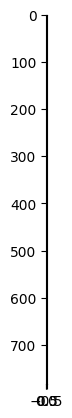

In [52]:
test_prediction(10, w1,b1,w2,b2)